In [1]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
from src.data import SPGDataset
import numpy as np
dataset = SPGDataset(root="../data/spg")

def normalize_absolute_coords(points):
	centroid = np.mean(points, axis=0)
	points -= centroid
	furthest_distance = np.max(np.sqrt(np.sum(abs(points)**2,axis=-1)))
	points /= furthest_distance

	return points

In [32]:
os.listdir("../data/spg/preprocessed/")

['backpack.npz',
 'calculator.npz',
 'campfire.npz',
 'flower.npz',
 'ice_cream.npz',
 'duck.npz',
 'cactus.npz',
 'coffee_cup.npz',
 'ant.npz',
 'butterfly.npz',
 'ambulance.npz',
 'angel.npz',
 'apple.npz',
 'pineapple.npz',
 'basket.npz',
 'drill.npz',
 'airplane.npz',
 'suitcase.npz',
 'crab.npz',
 'pig.npz',
 'candle.npz',
 'alarm_clock.npz',
 'house.npz',
 'face.npz',
 'bulldozer.npz']

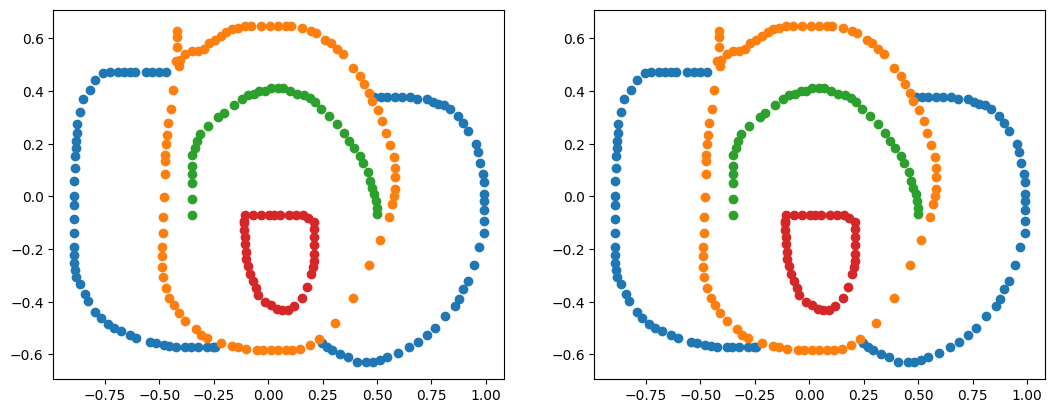

In [39]:
pos1 = dataset[67]['pos_absolute']
pos2 = normalize_absolute_coords(dataset[67]['pos_relative'].cumsum(axis=0))

import matplotlib.pyplot as plt
labels = dataset[67]['label']

fig, axis = plt.subplots(1, 2, figsize=(6.4 * 2, 4.8))

for label in np.unique(labels):
    axis[0].scatter(pos1[label == labels][:, 0], -pos1[label == labels][:, 1])

for label in np.unique(labels):
    axis[1].scatter(pos2[label == labels][:, 0], -pos2[label == labels][:, 1])
    

(np.float64(-0.9859748035669327),
 np.float64(1.0843749791383743),
 np.float64(-0.6944027334451676),
 np.float64(0.7088343888521195))

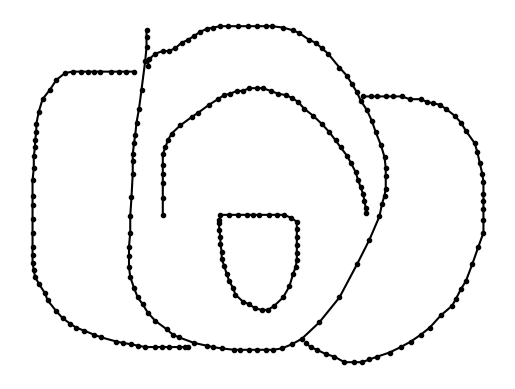

In [57]:
data = dataset[67]
pos = data['pos_absolute']
stroke_id = data['stroke_id']

for stroke in np.unique(stroke_id):
    plt.plot(pos[stroke == stroke_id][:, 0], -pos[stroke == stroke_id][:, 1], c='black', marker='.')

plt.axis("off")

(np.float64(-0.9859748035669327),
 np.float64(1.0843749791383743),
 np.float64(-0.6944027334451676),
 np.float64(0.7088343888521195))

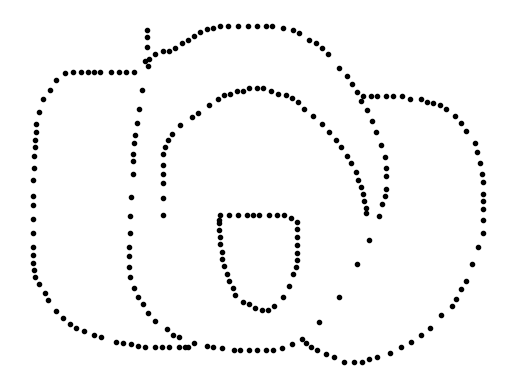

In [62]:
plt.scatter(pos[:, 0], -pos[:, 1], c='black', marker='.')
plt.axis("off")

(np.float64(-0.9859748035669327),
 np.float64(1.0843749791383743),
 np.float64(-0.6944027334451676),
 np.float64(0.7088343888521195))

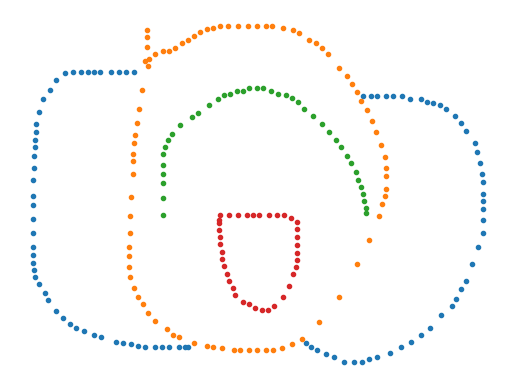

In [60]:
for label in np.unique(labels):
    plt.scatter(pos[label == labels][:, 0], -pos[label == labels][:, 1], marker='.')

plt.axis("off")

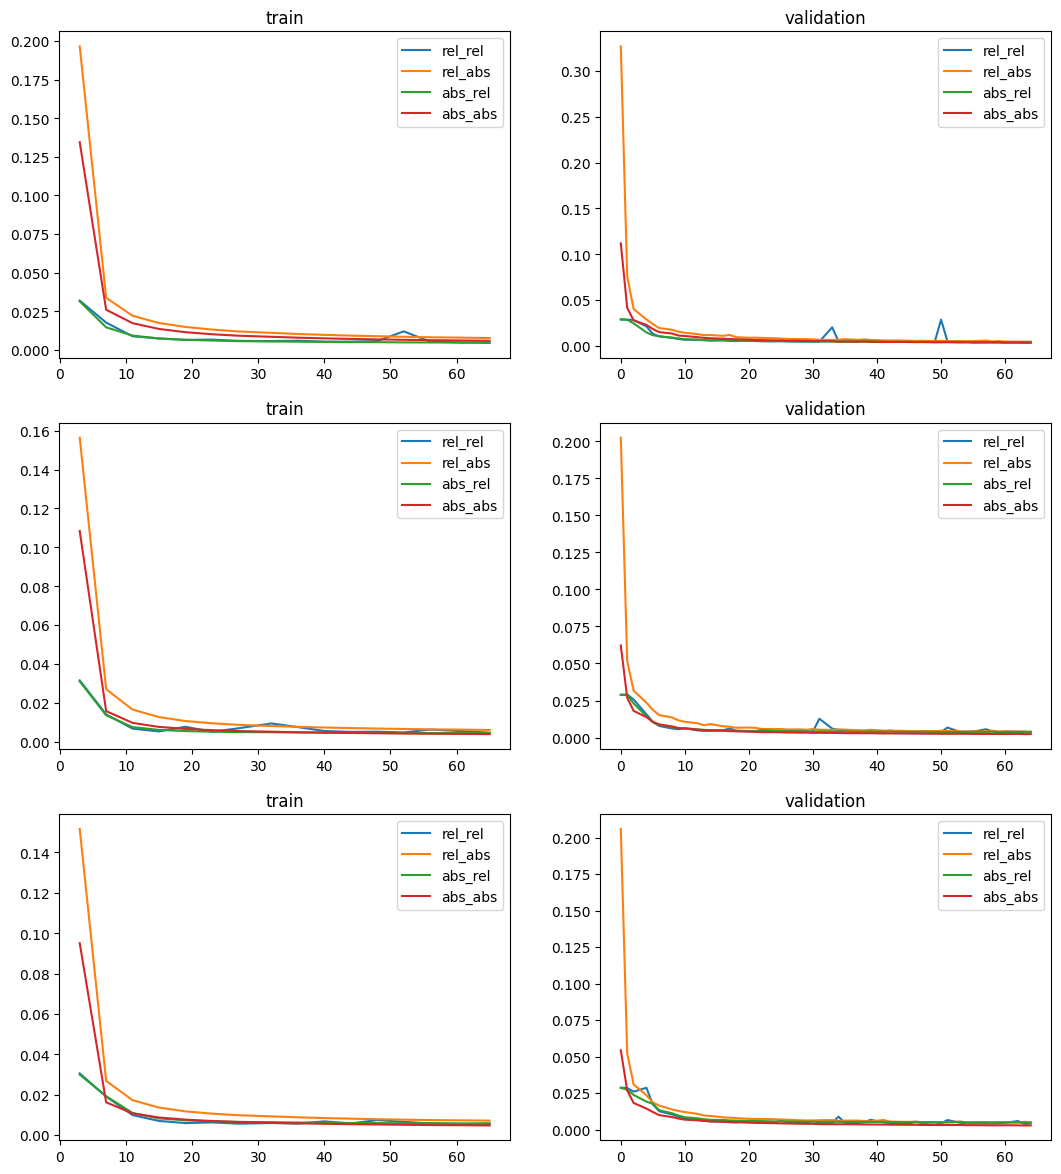

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axis = plt.subplots(3, 2, figsize=(6.4 * 2, 3 * 4.8))

for i, decoder in enumerate(['nar', 'nar-enc', 'ffn']):
    rel_rel_metrics = pd.read_csv(f"../../sketch_representations/checkpoints/experiment2/rel_rel_{decoder}_42/lightning_logs/version_0/metrics.csv")
    rel_abs_metrics = pd.read_csv(f"../../sketch_representations/checkpoints/experiment2/rel_abs_{decoder}_42/lightning_logs/version_0/metrics.csv")
    abs_rel_metrics = pd.read_csv(f"../../sketch_representations/checkpoints/experiment2/abs_rel_{decoder}_42/lightning_logs/version_0/metrics.csv")
    abs_abs_metrics = pd.read_csv(f"../../sketch_representations/checkpoints/experiment2/abs_abs_{decoder}_42/lightning_logs/version_0/metrics.csv")

    rel_rel_train = rel_rel_metrics['train_loss'][~rel_rel_metrics['train_loss'].isna()]
    rel_abs_train = rel_abs_metrics['train_loss'][~rel_abs_metrics['train_loss'].isna()]
    abs_rel_train = abs_rel_metrics['train_loss'][~abs_rel_metrics['train_loss'].isna()]
    abs_abs_train = abs_abs_metrics['train_loss'][~abs_abs_metrics['train_loss'].isna()]

    axis[i,0].plot(rel_rel_train, label='rel_rel')
    axis[i,0].plot(rel_abs_train, label='rel_abs')
    axis[i,0].plot(abs_rel_train, label='abs_rel')
    axis[i,0].plot(abs_abs_train, label='abs_abs')
    axis[i,0].set_title('train')
    axis[i,0].legend()


    rel_rel_valid = rel_rel_metrics['val_loss'][~rel_rel_metrics['val_loss'].isna()]
    rel_abs_valid = rel_abs_metrics['val_loss'][~rel_abs_metrics['val_loss'].isna()]
    abs_rel_valid = abs_rel_metrics['val_loss'][~abs_rel_metrics['val_loss'].isna()]
    abs_abs_valid = abs_abs_metrics['val_loss'][~abs_abs_metrics['val_loss'].isna()]

    axis[i,1].plot(rel_rel_valid, label='rel_rel')
    axis[i,1].plot(rel_abs_valid, label='rel_abs')
    axis[i,1].plot(abs_rel_valid, label='abs_rel')
    axis[i,1].plot(abs_abs_valid, label='abs_abs')
    axis[i,1].set_title('validation')
    axis[i,1].legend()

In [25]:
!ls ../../sketch_representations/checkpoints/experiment2/ | grep -E "_ar_|_ar-enc"

abs_abs_ar-enc_1999
abs_abs_ar-enc_42
abs_abs_ar_1999
abs_abs_ar_42
abs_rel_ar-enc_1999
abs_rel_ar-enc_42
abs_rel_ar_1999
abs_rel_ar_42
abs_rel_ar_5342
rel_abs_ar-enc_1999
rel_abs_ar-enc_42
rel_abs_ar_1999
rel_abs_ar_42
rel_abs_ar_5342
rel_rel_ar-enc_1999
rel_rel_ar-enc_42
rel_rel_ar-enc_5342
rel_rel_ar_1999
rel_rel_ar_42
rel_rel_ar_5342
